# Process Step Downtime Feature Importance Study

## Case Study
A previous review on the downtime of each process step have found step 2 to have significant standard deviation.

This implies potential issues that can be addressed to improve consistency of the process.

## Benefit
By optimizing the process which shows significant spread, companies can:
- Improve consistency of production throughput
- Enable next stage of optimization to reduce the downtime of each production
- Minimize process overruns

# Synthetic Data Generation
Simulate process for study

In [11]:
import pandas as pd

df_downtimes = pd.read_excel(r"data\process_step_downtime.xlsx")
# df_downtimes

In [12]:
sr_step2 = df_downtimes["Step 2"]
# sr_step2

In [13]:
# generate randomized process data trends at varying length
import numpy as np
import pandas as pd

ls_batch_data = []

for row in sr_step2:
    # print(f"{row}")

    # Temperature Randomization
    T = np.random.normal(loc=30, scale=3, size=row)  

    # Pressure Randomization
    P = np.random.normal(loc=1.0, scale=0.2, size=row)

    # Level Randomization
    l = np.random.normal(loc=0.3, scale=0.05, size=row)

    rdy_duration = np.random.randint(3, 5)

    # update last items in l to higher level
    l[-rdy_duration:] = np.random.normal(loc=15, scale=0.1, size=rdy_duration)

    # update last items of temperature to gradually increase to 50 deg C
    T_start = T[row - rdy_duration]
    step_size = (50 - T_start) / rdy_duration
    step_sequence = np.arange(1, rdy_duration + 1) * step_size
    T_transition = T_start + step_sequence

    T[-rdy_duration:] = T_transition 

    # Machine ID
    machine_id = np.random.randint(1, 4)

    ls_batch_data.append(
        pd.DataFrame({
            "T": T,
            "P": P,
            "lvl": l,
            "machine_id": machine_id,
            "downtime": row
            })
    )

# ls_batch_data

## Feature Engineering

### Assumptions
- Temperature setpoint is 49
- Level setpoint is 14

In [14]:
from scipy.stats import linregress # Excellent for basic slope calculation

# Add deviation from Temperature Setpoint or Setpoints
T_sp = 49
L_sp = 14

for index, element in enumerate(ls_batch_data):
    element["dT PV-SP"] = element["T"] - T_sp
    element["dL PV-SP"] = element["lvl"] - L_sp

    # Gradient of T, P, and Lvl;
    # if index == 0:

    element["dTdt"] = element["T"].diff().fillna(0).copy()
    element["dPdt"] = element["P"].diff().fillna(0).copy()
    element["dLdt"] = element["lvl"].diff().fillna(0).copy()

    # Normalized Time
    N = len(element)
    if N <= 1:
        # Avoid division by zero if there's only 0 or 1 row
        normalized_time = np.zeros(N)
    else:
        # Normalization formula: index / (N - 1)
        # If N=5, the indices are 0, 1, 2, 3, 4. Dividing by 4 gives 0, 0.25, 0.5, 0.75, 1.0
        normalized_time = np.arange(N) / (N - 1)
    
    # Add the new normalized time column to the DataFrame
    element['Normalized_Time'] = normalized_time

    # Batch ID
    element["batch_id"] = index

In [15]:
ls_batch_data[0]

,T,P,lvl,machine_id,downtime,dT PV-SP,dL PV-SP,dTdt,dPdt,dLdt,Normalized_Time,batch_id
0,30.525271,1.117892,0.335405,2,34,-18.474729,-13.664595,0.000000,0.000000,0.000000,0.000000,0
1,29.061061,1.121863,0.242318,2,34,-19.938939,-13.757682,-1.464210,0.003971,-0.093086,0.030303,0
2,34.173161,1.079678,0.331191,2,34,-14.826839,-13.668809,5.112101,-0.042185,0.088872,0.060606,0
3,33.104235,0.432809,0.290708,2,34,-15.895765,-13.709292,-1.068926,-0.646869,-0.040482,0.090909,0
4,22.923954,1.182253,0.306684,2,34,-26.076046,-13.693316,-10.180282,0.749444,0.015976,0.121212,0
5,32.049318,0.702840,0.293793,2,34,-16.950682,-13.706207,9.125365,-0.479413,-0.012891,0.151515,0
6,25.117300,0.807881,0.197056,2,34,-23.882700,-13.802944,-6.932019,0.105041,-0.096736,0.181818,0
7,26.187405,1.274997,0.317447,2,34,-22.812595,-13.682553,1.070105,0.467116,0.120390,0.212121,0
8,29.224836,0.814644,0.303602,2,34,-19.775164,-13.696398,3.037432,-0.460353,-0.013845,0.242424,0
9,31.470058,1.077348,0.424251,2,34,-17.529942,-13.575749,2.245221,0.262704,0.120650,0.272727,0


In [16]:
# Rearrange row to end of the column for machine learning
target_column = "downtime"

all_columns = ls_batch_data[0].columns.tolist()  # NOTE Assumes all dataframes share same format

columns_without_target = [col for col in all_columns if col != target_column]

new_column_order = columns_without_target + [target_column]

for index, element in enumerate(ls_batch_data):
    element = element[new_column_order]

    ls_batch_data[index] = element


ls_batch_data[0]

,T,P,lvl,machine_id,dT PV-SP,dL PV-SP,dTdt,dPdt,dLdt,Normalized_Time,batch_id,downtime
0,30.525271,1.117892,0.335405,2,-18.474729,-13.664595,0.000000,0.000000,0.000000,0.000000,0,34
1,29.061061,1.121863,0.242318,2,-19.938939,-13.757682,-1.464210,0.003971,-0.093086,0.030303,0,34
2,34.173161,1.079678,0.331191,2,-14.826839,-13.668809,5.112101,-0.042185,0.088872,0.060606,0,34
3,33.104235,0.432809,0.290708,2,-15.895765,-13.709292,-1.068926,-0.646869,-0.040482,0.090909,0,34
4,22.923954,1.182253,0.306684,2,-26.076046,-13.693316,-10.180282,0.749444,0.015976,0.121212,0,34
5,32.049318,0.702840,0.293793,2,-16.950682,-13.706207,9.125365,-0.479413,-0.012891,0.151515,0,34
6,25.117300,0.807881,0.197056,2,-23.882700,-13.802944,-6.932019,0.105041,-0.096736,0.181818,0,34
7,26.187405,1.274997,0.317447,2,-22.812595,-13.682553,1.070105,0.467116,0.120390,0.212121,0,34
8,29.224836,0.814644,0.303602,2,-19.775164,-13.696398,3.037432,-0.460353,-0.013845,0.242424,0,34
9,31.470058,1.077348,0.424251,2,-17.529942,-13.575749,2.245221,0.262704,0.120650,0.272727,0,34


## Feature Importance

In [17]:
import xgboost as xgb
from sklearn.model_selection import GroupKFold, cross_val_score, LeaveOneGroupOut

# Concatenate the dataframes into a single dataframe
combined_df = pd.concat(ls_batch_data, axis=0, ignore_index=True)

# Grouping
groups = combined_df['batch_id']

# Split the dataframe into X and y
X = combined_df.drop(columns=['downtime'])
y = combined_df['downtime']

gkf = GroupKFold(n_splits=5)
model = xgb.XGBRegressor(importance_type='gain')

# Cross-validate to ensure the features are actually predictive across batches
scores = cross_val_score(model, X, y, groups=groups, cv=gkf, scoring='r2')
print(f"Mean R2 across batches: {scores.mean()}")

logo = LeaveOneGroupOut()

for train_idx, test_idx in logo.split(X, y, groups=groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Fit the model
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        # early_stopping_rounds=50,
        verbose=False
    )

    # NOTE observed negative average R2 value. To go with sanity check 


Mean R2 across batches: -0.8074419021606445


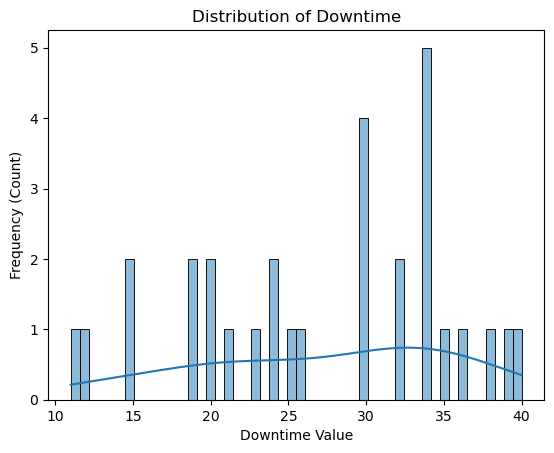

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

#  Downtime Histogram <See distribution to see any patterns>
sns.histplot(sr_step2, bins=50, kde=True)

plt.title('Distribution of Downtime')
plt.xlabel('Downtime Value')
plt.ylabel('Frequency (Count)')
plt.show()

# FINDINGS: Observed peaks around 30 and 35. Not enough data points / samples to observe distribution clearly and thus make any extrapolations.
# ACTION: Need more datapoints 

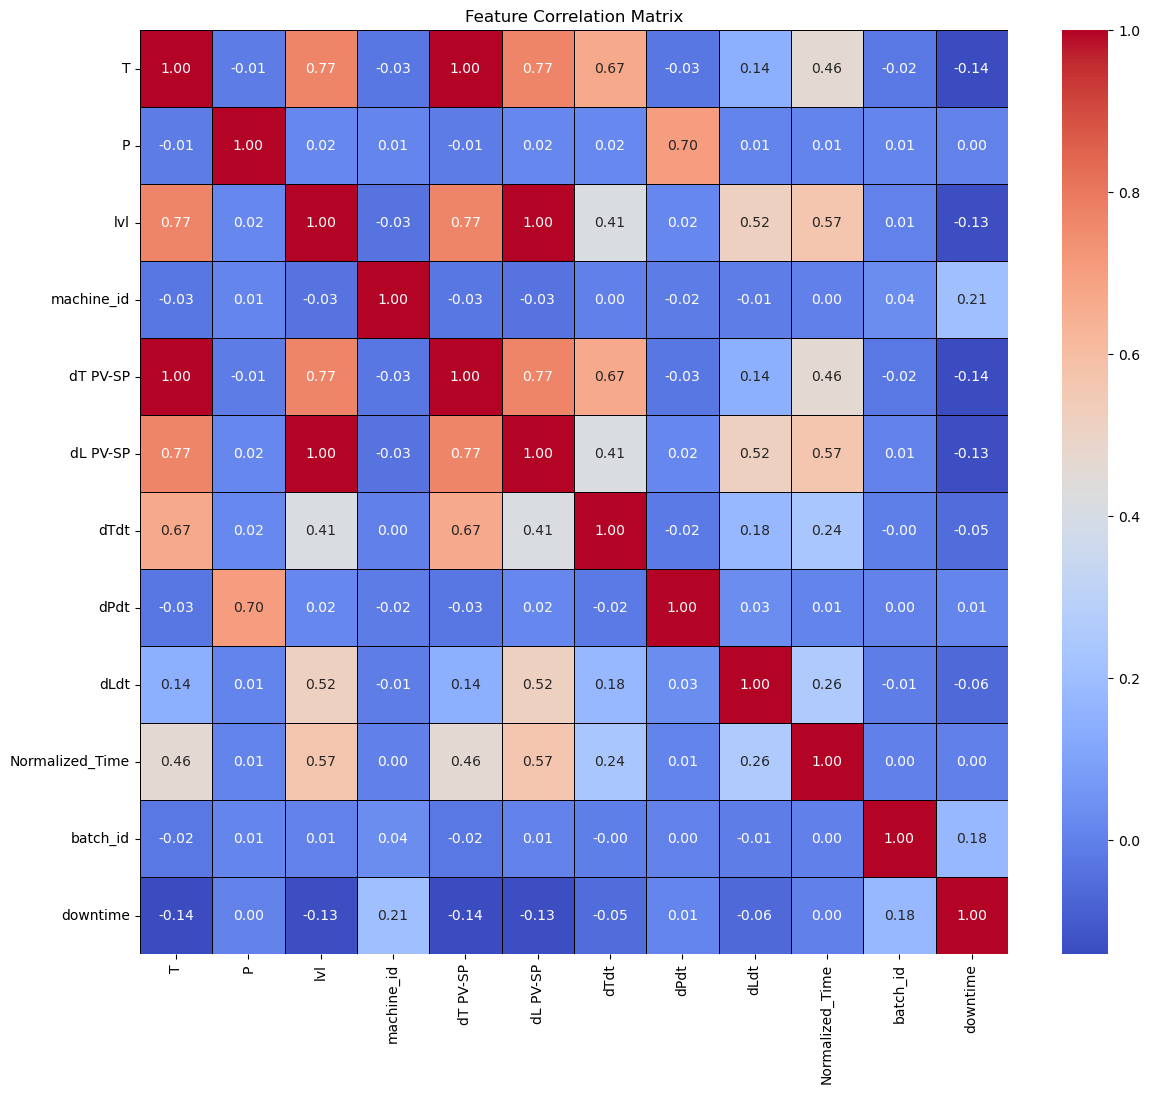


--- Top 10 Strongest Correlations (Magnitude) ---
                   T         P       lvl  machine_id  dT PV-SP  dL PV-SP  \
downtime    0.140935  0.002846  0.133498    0.205489  0.140935  0.133498   
machine_id  0.027037  0.013670  0.034491    1.000000  0.027037  0.034491   
batch_id    0.024641  0.011243  0.005184    0.035398  0.024641  0.005184   
T           1.000000  0.013168  0.772198    0.027037  1.000000  0.772198   
dT PV-SP    1.000000  0.013168  0.772198    0.027037  1.000000  0.772198   
lvl         0.772198  0.015976  1.000000    0.034491  0.772198  1.000000   
dL PV-SP    0.772198  0.015976  1.000000    0.034491  0.772198  1.000000   
dLdt        0.142231  0.006416  0.515163    0.009265  0.142231  0.515163   
dTdt        0.668661  0.023006  0.412831    0.000566  0.668661  0.412831   
dPdt        0.029123  0.702728  0.017811    0.015479  0.029123  0.017811   

                dTdt      dPdt      dLdt  Normalized_Time  batch_id  downtime  
downtime    0.053132  0.011371  

In [19]:

import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix <See any potential relationships in the data>
corr_matrix = combined_df.corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=.5, linecolor='black')
plt.title('Feature Correlation Matrix')
plt.show()

# OPTIONAL: View the raw correlation values in the console
print("\n--- Top 10 Strongest Correlations (Magnitude) ---")
print(corr_matrix.abs().sort_values(by='downtime', ascending=False).head(10))

# FINDINGS: Weak correlations throughout key sensor / feature not in sensor list.
# ACTION: Need to expand search.


In [20]:
# Results

import pandas as pd

importances = model.feature_importances_
feature_names = X.columns

# Create a summary table
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

            Feature  Importance
10         batch_id    0.616256
3        machine_id    0.383744
0                 T    0.000000
2               lvl    0.000000
1                 P    0.000000
5          dL PV-SP    0.000000
4          dT PV-SP    0.000000
6              dTdt    0.000000
7              dPdt    0.000000
8              dLdt    0.000000
9   Normalized_Time    0.000000


## Visualization

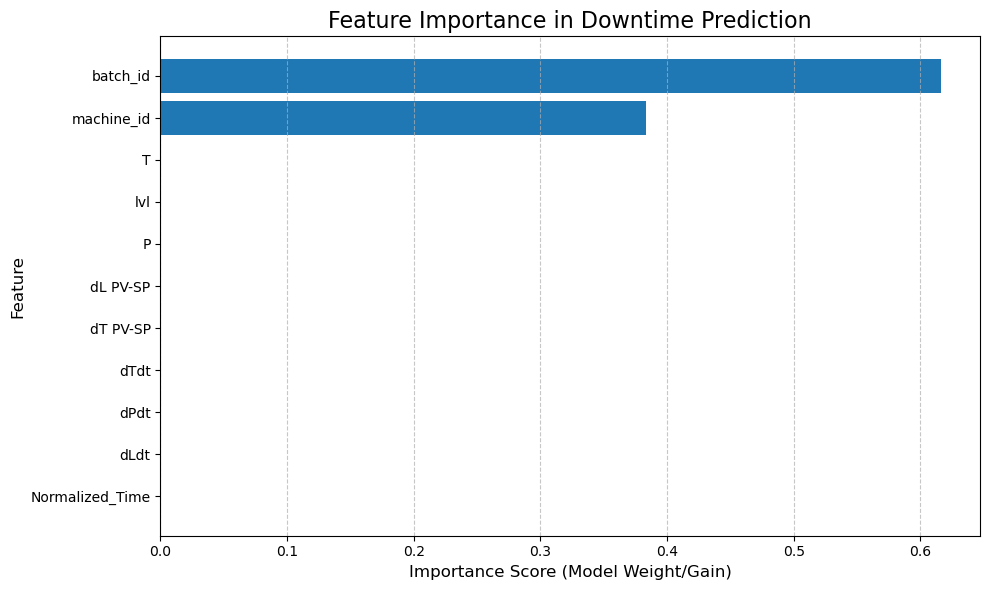

In [22]:
sorted_df = feature_importance_df.iloc[::-1].reset_index(drop=True)

plt.figure(figsize=(10, 6))

# The function plt.barh() stands for "bar horizontal"
plt.barh(
    sorted_df['Feature'],  # The categories (Y-axis)
    sorted_df['Importance'] # The length of the bars (X-axis)
)

# 3. Adding labels and titles for professional appearance
plt.title('Feature Importance in Downtime Prediction', fontsize=16)
plt.xlabel('Importance Score (Model Weight/Gain)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7) # Add horizontal gridlines for easier reading
plt.tight_layout()
plt.show()

c:\Users\edwar\anaconda3\envs\MachineLearning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


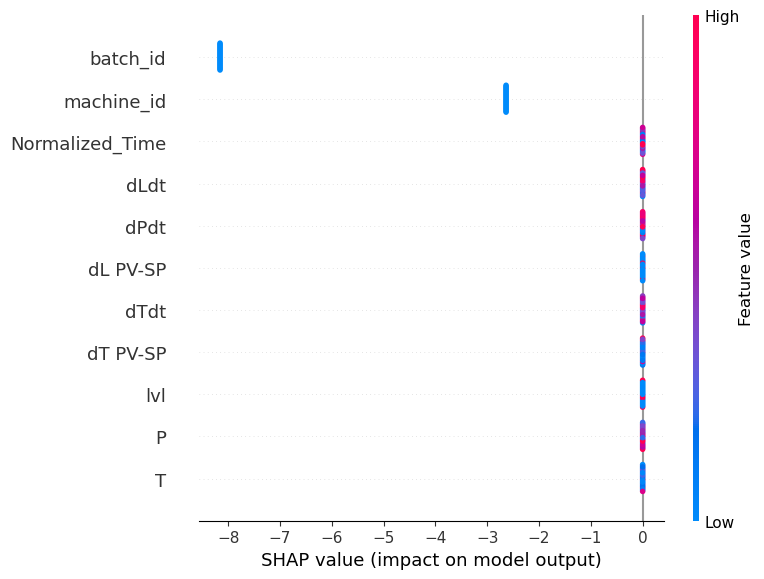

In [21]:
import shap

# Explain the model's predictions using SHAP
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Visualize the feature importance and their impact direction
shap.summary_plot(shap_values, X_test)